### RNN  for processing sequences

##### Recurrent Neurons and Layers
One neuron receiving inputs ,producing an output ,and sending that output back to itself 

-unrolling the network through time
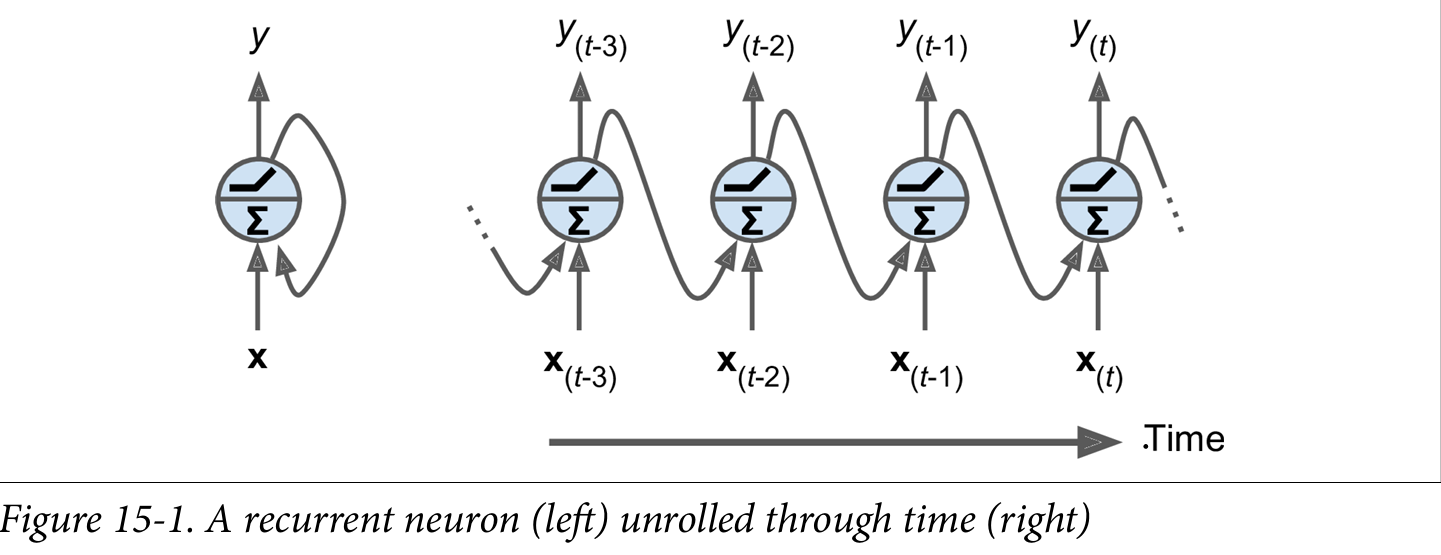 

-create a layer of recurrent neurons 
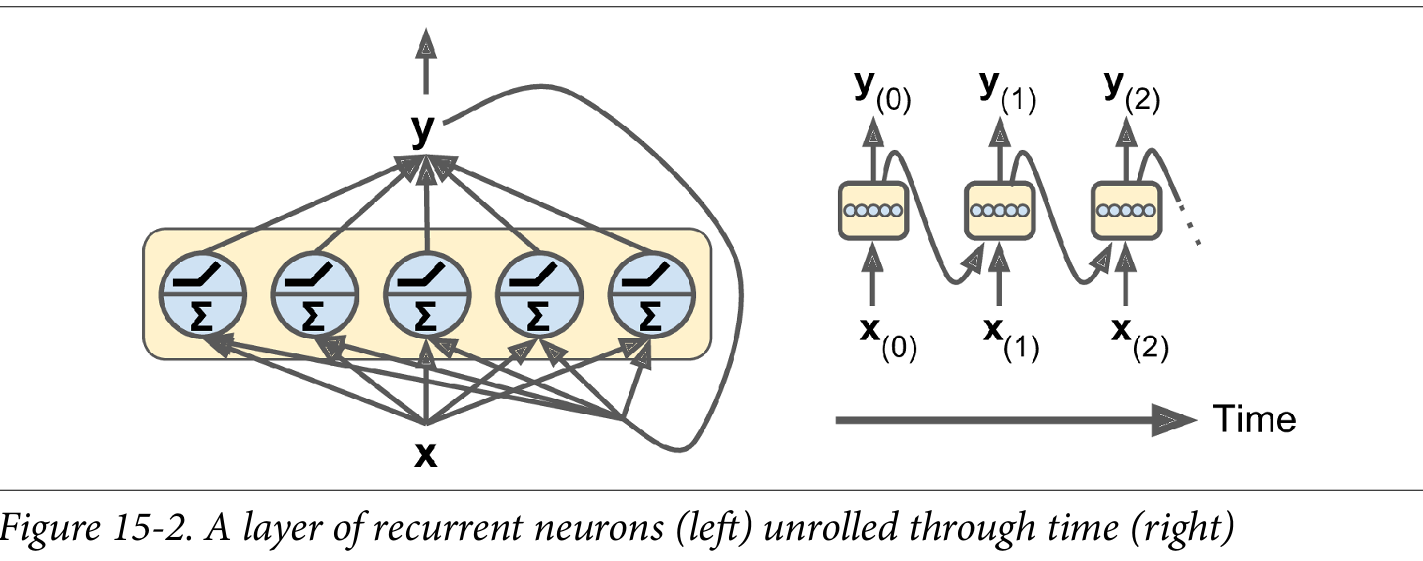


-output of a recurrent layer for a single instance
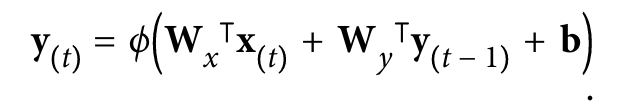

-outputs of a layer of recurrent neurons for all instances in a mini batch
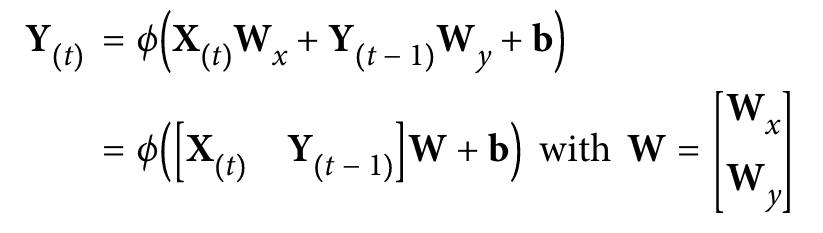

-A cells hidden state and its ouput may be different
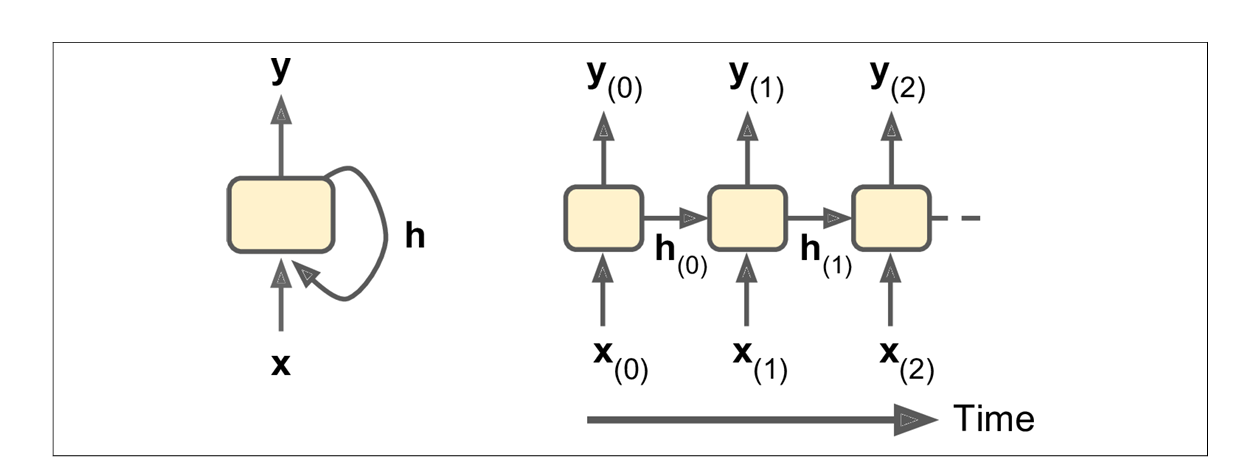




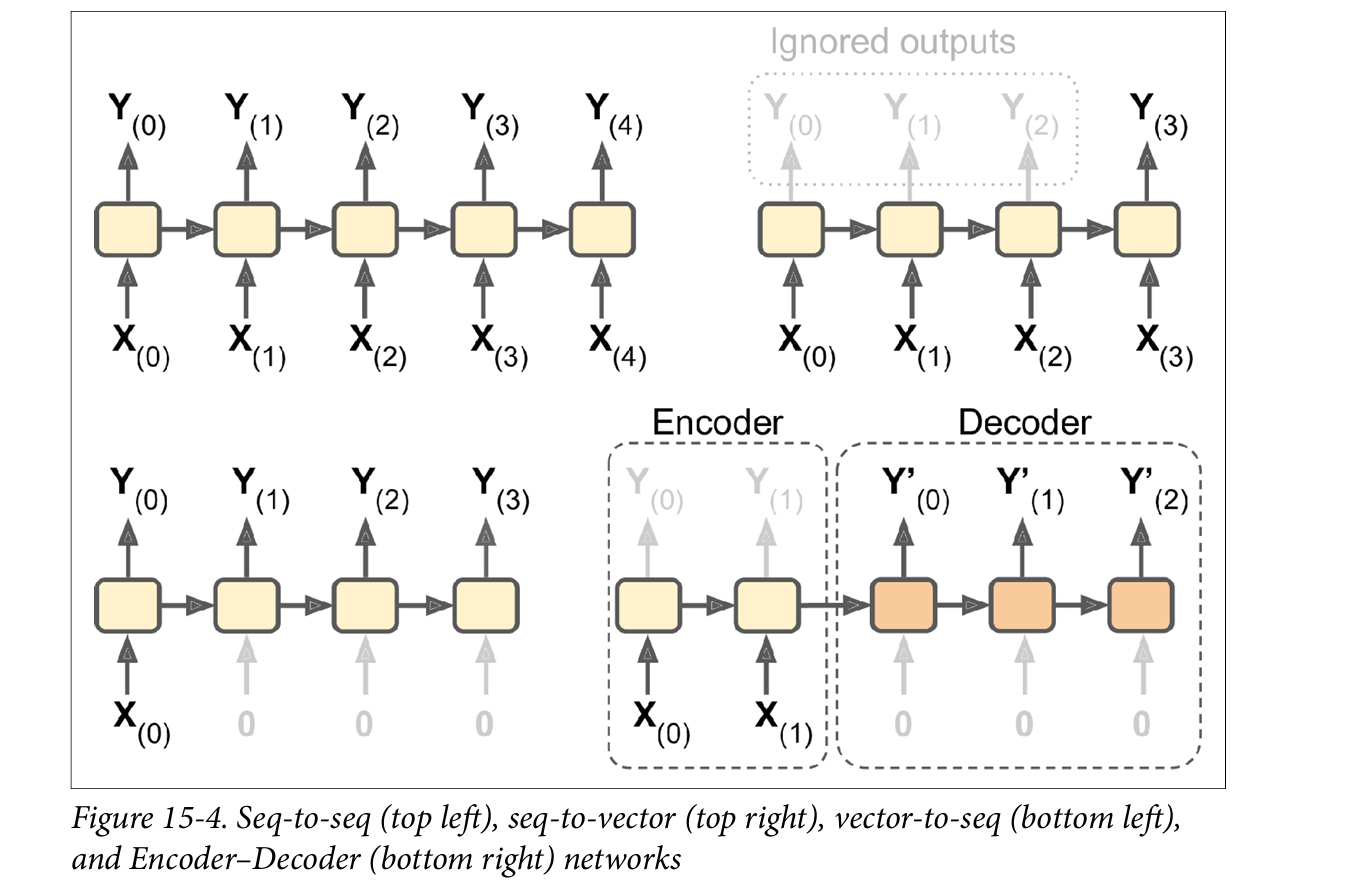

### Training RNNs
-Backpropagation throught time
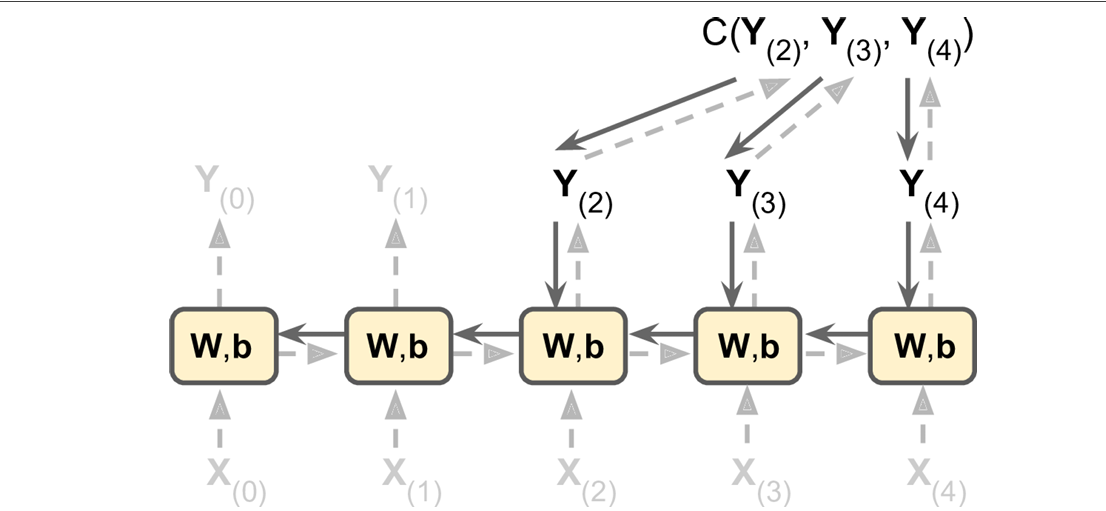


#### Time series forecasting
-the data will be a sequence of one or more values per time step ,this is called time series

-single value por time step is called univariate time series 
-multiple values per time step is called multivariate time series 
-A typical task is to predict future values .which is called forecasting 
-Another common task is to fill in the blanks  ,to predict missing values from the past

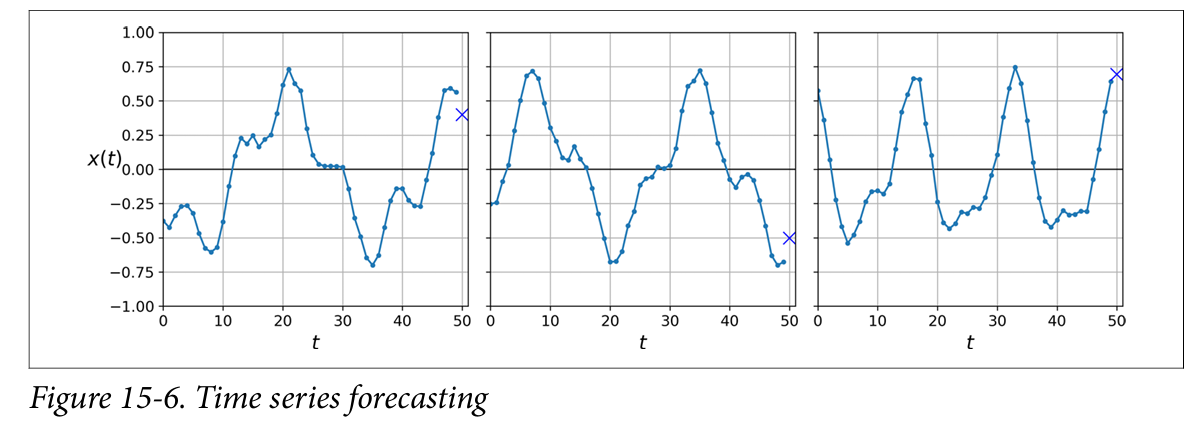

In [ ]:
import numpy as np
def generate_time_series(batch_size ,n_steps):
    freq1 ,freq2 ,offsets1 , offsets2 = np.random.rand(4 ,batch_size , 1)
    time = np.linspace(0 , 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 100))
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20))
    series += 0.1 * (np.random.rand(batch_size , n_steps) - 0.5) 
    return series[..., np.newaxis].astype(np.float32) 

#create a training set , a validation set and a test set
n_steps = 50
series = generate_time_series(10000 , n_steps + 1)
X_train , y_train = series[:7000 , :n_steps] , series[:7000 , -1]
X_valid , y_valid = series[7000:9000 , :n_steps] ,
series[7000:9000 , -1]
X_test , y_test = series[9000: , :n_steps] , series[9000: , -1]    


In [ ]:
#baseline metrics 

import keras

y_pred = X_valid[:, -1]
np.mean(keras.losse.mean_squared_error(y_valid,  y_pred))

model = keras.models.Sequential([
     keras.yaers.Flatten(inout_shape=[50 , 1]),
     keras.layers.Dense(1)

])
model.compile(loss = "mse" , optimizer = "adam")
model.fit(X_train , y_train , epochs = 20 , validation_data = (X_valid , y_valid))  

#### Implementing a Simple RNN

In [ ]:
model = keras.models.Sequential([
     keras.layers.SimpleRNN(1,input_shape=[None , 1])
])


#### Deep RNNs

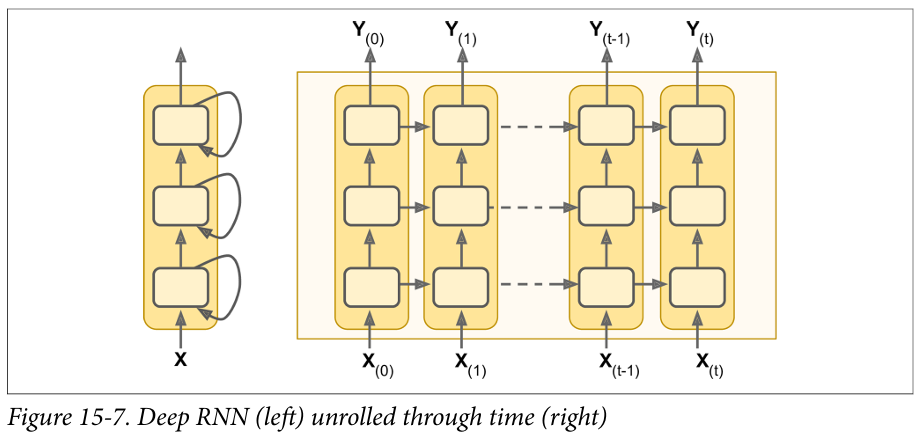

In [ ]:
#you can use SimpleRNN layers ,but we could add any other type
#of recurrent layer such as an LSTM layer or a GRU layer 

model = keras.models.Sequential([
        keras.layers.LSTM(20 , return_sequences = True , input_shape=[None , 1]),
        keras.layers.SimpleRNN(20, return_sequences = True),
        keras.layers.SimpleRNN(1) 

])

#Is preferible use  dense layer as output layer because it is more flexible and it is nottied to a specific type of recurrent layer.    

model = keras.models.Sequential([
        keras.layers.LSTM(20 , return_sequences = True , input_shape=[None , 1]),
        keras.layers.SimpleRNN(20),    
        keras.layers.Dense(1)
])
model.compile(loss = "mse" , optimizer = "adam")
model.fit(X_train , y_train , epochs = 20 , validation_data = (X_valid , y_valid))


### Forecasting Several Time Steps Ahead 

But what if we want to predict the next 10 values ?

-first option is to use a model we already trained   ,make it predict the next value,then add that value to the inputs ,and use the model again to predict the following value .

In [ ]:
series = generate_time_series(1 , n_steps + 10)
X_new , Y_new = series[:, :n_steps] , series[:, n_steps:]
X= X_new
for step in range(10):
    y_pred = model.predict(X[:, step:])[:, np.newaxis , :]
    X = np.concatenate([X , y_pred] , axis = 1) 
Y_pred = X[:, n_steps:]
np.mean(keras.losses.mean_squared_error(Y_new , Y_pred))    

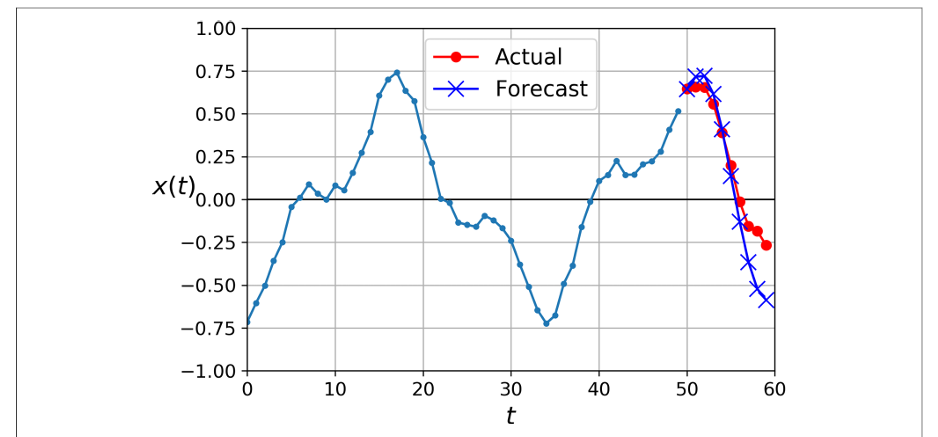

-The second option es to train an RNN to predict all 10 next values at once .We can still use a sequence to vector model ,but it will ouput 10 values instead of 1 

In [ ]:
series = generate_time_series(10000 , n_steps + 10)
X_train , y_train = series[:7000 , :n_steps] , series[:7000 , -10:,0]
X_valid , y_valid = series[7000:9000 , :n_steps] , series[7000:9000 , -10:,0]
X_test , y_test = series[9000: , :n_steps] , series[9000: , -10:,0]

#Now just need the output layer to have 10 neurons instead of 1
model = keras.models.Sequential([
        keras.layers.LSTM(20 , return_sequences = True , input_shape=[None , 1]),
        keras.layers.SimpleRNN(20),    
        keras.layers.Dense(10)
])  
y_pred = model.predict(X_new)
np.mean(keras.losses.mean_squared_error(Y_new , y_pred))

In [ ]:
#use a TimeDistributed layer to apply the same Dense layer to each time step of the output sequence 
model = keras.models.Sequential([
        keras.layers.LSTM(20 , return_sequences = True , input_shape=[None , 1]),
        keras.layers.SimpleRNN(20 , return_sequences = True),    
        keras.layers.TimeDistributed(keras.layers.Dense(10))
])

### LSTM cells

-proposed by Seep Hochreiter and Jurgen Schmidhuber in 1997

In [ ]:
model = keras.models.Sequential([
        keras.layers.LSTM(20 , return_sequences = True , input_shape=[None , 1]),
        keras.layers.LSTM(20 , return_sequences = True),    
        keras.layers.TimeDistributed(keras.layers.Dense(10))        
])

#or

model = keras.models.Sequential([
        keras.layers.RNN(keras.layers.LSTMCell(20), return_sequences = True, input_shape=[None , 1]),
        keras.layers.RNN(keras.layers.LSTMCell(20), return_sequences = True),
        keras.layers.TimeDistributed(keras.layers.Dense(10))
])

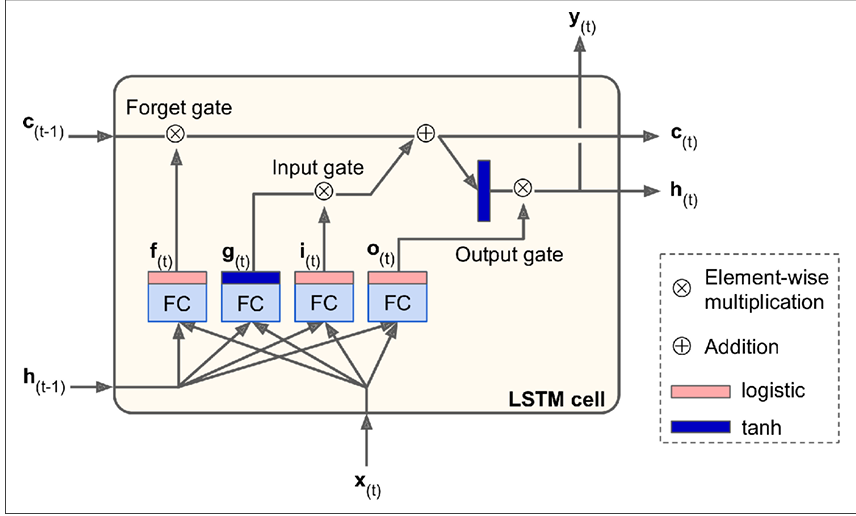

#### GRU cells
-Proposed by  Kyunghyun
Cho et al. in a 2014 paper ,that also introduced the encoder-decoder network
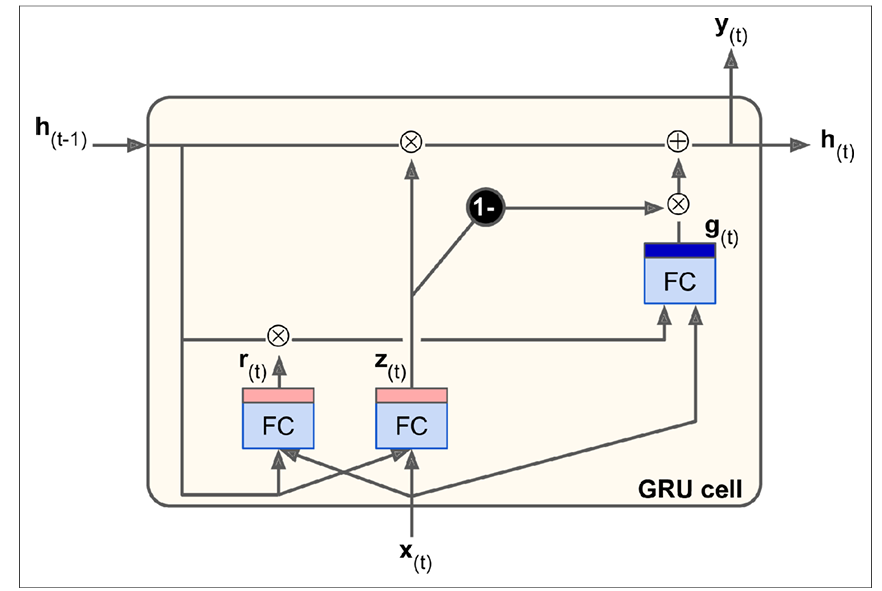

In [ ]:
#use a convolutional layer to process the input sequence before feeding it to the recurrent layers
model = keras.models.Sequential([
keras.layers.Conv1D(filters=20, kernel_size=4, strides=2, padding="valid",
input_shape=[None, 1]),
keras.layers.GRU(20, return_sequences=True),
keras.layers.GRU(20, return_sequences=True),
keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train[:, 3::2], epochs=20,
validation_data=(X_valid, Y_valid[:, 3::2]))

### WaveNet
-In a 2016 paper,13 Aaron van den Oord and other DeepMind researchers introduced
an architecture called WaveNet.
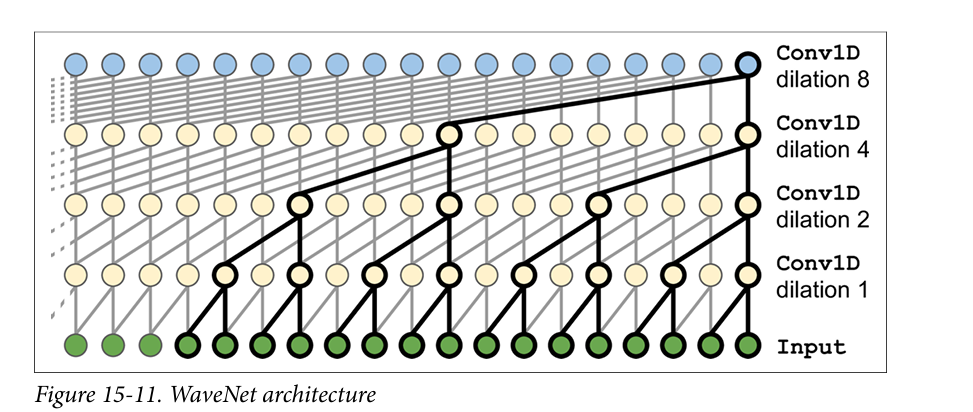

In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.InputLayer(input_shape=[None, 1]))
for rate in (1, 2, 4, 8) * 2:
model.add(keras.layers.Conv1D(filters=20, kernel_size=2, padding="causal",
activation="relu", dilation_rate=rate))
model.add(keras.layers.Conv1D(filters=10, kernel_size=1))
model.compile(loss="mse", optimizer="adam", metrics=[last_time_step_mse])
history = model.fit(X_train, Y_train, epochs=20,
validation_data=(X_valid, Y_valid))

### Generating Shakespearean Text Using a Character RNN

-Char RNN can then be used to generate novel text , one charaacter at a time .

In [4]:
import keras
from tensorflow.keras.preprocessing.text import Tokenizer
#Creating the training Dataset
shakespeare_url = "https://homl.info/shakespeare" 
filepath = keras.utils.get_file("shakespeare.txt", shakespeare_url)
with open(filepath) as f :
    shakespeare_text = f.read() 

#Endoing every character as an Integer
tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts([shakespeare_text])


In [5]:
tokenizer.texts_to_sequences(['First'])


[[20, 6, 9, 8, 3]]

In [7]:
tokenizer.sequences_to_texts([[20, 6, 9, 8, 3]])

['f i r s t']

In [ ]:
max_id = len(tokenizer.word_index)
# dataset_size should be the number of characters, not documents (which is always 1 for single text)
# This will be set after encoding, for now just use a placeholder

In [47]:
import numpy as np
#econde the full text so each character is replaced by its integer index

[encoded]  = np.array(tokenizer.texts_to_sequences([shakespeare_text])) - 1
dataset_size = len(encoded)

In [48]:
#SPLIT A SEQUANTIAL DATASET
# How you split your dataset depends  of your  dataset type ,is stationary or not ,
# and the problem you are trying to solve. In a sequential dataset you can not split
#  it randomly because it will break the temporal structure of the data. You need to 
# split it in a way that the training set is before the validation set and the validation
#  set is before the test set.   

#in this case ,lets take the firts 90 % of the text for the training set 
import tensorflow as tf

train_size = dataset_size *90 // 100 
dataset = tf.data.Dataset.from_tensor_slices(encoded[:train_size]) 





we will use the datasets window method to convert this long sequence of characters into many smaller windows of text  ,the RNN will be unrolled only over the lenght of these substrings 
This is called truncated backpropagation through time

In [49]:
n_steps = 100 
window_length = n_steps + 1

# Check data sizes
print(f"Encoded length: {len(encoded)}")
print(f"Train size: {train_size}")
print(f"Window length: {window_length}")

# Create sliding windows using numpy
train_data = encoded[:train_size]
print(f"Train data length: {len(train_data)}")
print(f"Num windows: {len(train_data) - window_length + 1}")

if len(train_data) > window_length:
    windows_list = []
    for i in range(len(train_data) - window_length + 1):
        windows_list.append(train_data[i:i+window_length])
    
    windows_array = np.stack(windows_list)
    print(f"Windows array shape: {windows_array.shape}")
    
    # Convert to TensorFlow dataset
    dataset = tf.data.Dataset.from_tensor_slices(windows_array.astype(np.float32))
    print("Dataset created successfully")
else:
    print("ERROR: Not enough training data for the window size")

Encoded length: 1115394
Train size: 1003854
Window length: 101
Train data length: 1003854
Num windows: 1003754
Windows array shape: (1003754, 101)
Dataset created successfully


In [50]:
#we need to suffle thse windows ,then we can batch the windows and separate the inputs from the target
batch_size = 32
dataset = dataset.map(lambda window: (window[:-1], window[1:]))
dataset = dataset.shuffle(10000).batch(batch_size)

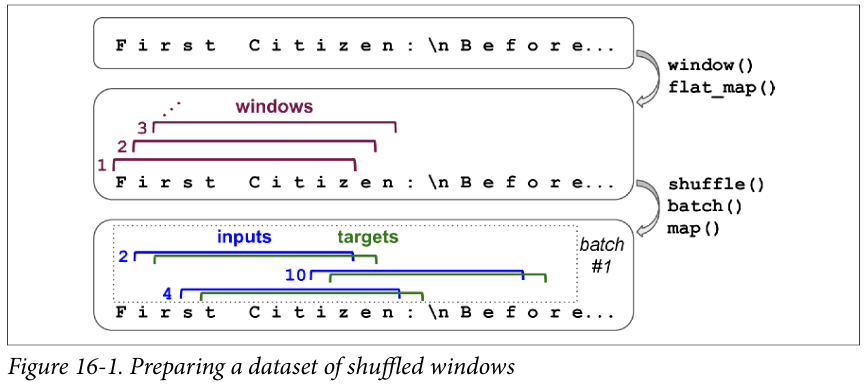

In [52]:
dataset = dataset.map(lambda X_batch, Y_batch: (tf.one_hot(tf.cast(X_batch, tf.int32), depth=max_id), Y_batch))

dataset = dataset.prefetch(1)

### Building and training the Char-RNN Model 

In [ ]:
model = keras.models.Sequential([
    keras.layers.GRU(128, return_sequences=True, input_shape=[None, max_id] 
                     ,dropout=0.2,recurrent_dropout=0.2),
    keras.layers.GRU(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.TimeDistributed(keras.layers.Dense(max_id, activation="softmax"))                     

])

model.compile(loss = 'sparse_categorical_crossentropy' , optimizer ='adam')
history = model.fit(dataset, epochs=20)

In [ ]:
def preprocess(texts) :
    X = np.array(tokenizer.texts_to_sequences(texts)) - 1
    return tf.one_hot(tf.cast(X, tf.int32), depth=max_id)


#Now lets use the model to predict the next letter in some text
X_new = preprocess(["ROMEO: "])
y_pred = model.predict(X_new)
tokenizer.sequences_to_texts(y_pred + 1)[0][-1]

#### Generating fake shakesperean text 


In [ ]:
def next_char(text, temperature=1):
    X_new = preprocess([text])
    y_proba = model.predict(X_new, verbose=0)[0, -1, :]
    rescaled_logits = tf.math.log(y_proba + 1e-7) / temperature
    char_id = tf.random.categorical(tf.expand_dims(rescaled_logits, 0), num_samples=1)[0, 0]
    return tokenizer.sequences_to_texts([[int(char_id.numpy()) + 1]])[0]


def complete_text(text, n_chars=50, temperature=1):
    for _ in range(n_chars):
        text += next_char(text, temperature)
    return text


In [ ]:
print(complete_text("t", temperature=0.2))
print(complete_text("w", temperature=1))
print(complete_text("w", temperature=2))

### Stateful RNN
-preserve this final state after processing one training batch and use it as the initial state for the next training batch ,this way the model can learn long-term patterns despite only backpropagating through short sequences
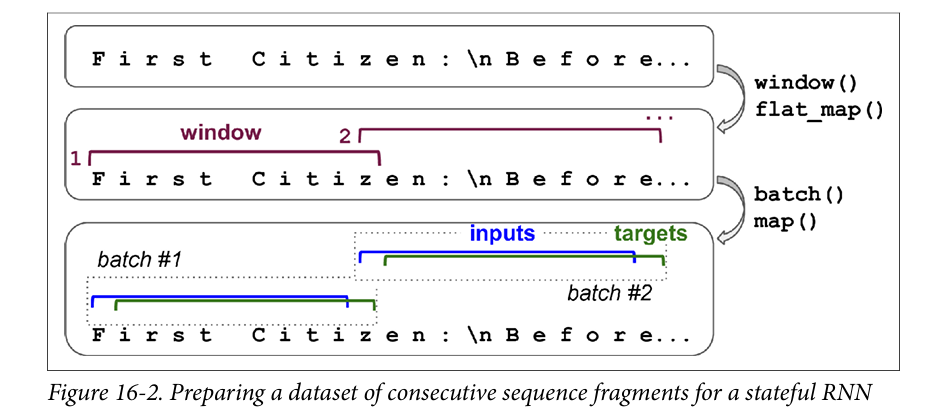

In [ ]:
model = keras.model.Sequential([
    keras.layers.GRU(128, return_sequences=True, stateful=True, dropout=0.2, recurrent_dropout=0.2,batch_input_shape=[batch_size, None, max_id]),
    keras.layers.GRU(128, return_sequences=True, stateful=True, dropout=0.2, recurrent_dropout=0.2),
    keras.layers.TimeDistributed(keras.layers.Dense(max_id, activation="softmax"))
])
#and the end of each epoch we need to reset the states of the model
class ResetStatesCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        self.model.reset_states()


model.compile(loss='sparse_categorical_crossentropy', optimizer='adam')
history = model.fit(dataset, epochs=20, callbacks=[ResetStatesCallback()])  

### Sentiment Analysis
-use a IMDb reviews dataset

In [3]:
import keras
(X_train , y_train) ,(X_test , y_test) = keras.datasets.imdb.load_data()
X_train[0][:10]


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]

In [7]:
%pip install -q tensorflow-datasets importlib_resources

#Using tensorflow datasets
import tensorflow_datasets as tfds
imdb , info = tfds.load("imdb_reviews" , with_info = True , as_supervised = True)
train__size = info.splits["train"].num_examples
train__size


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


c:\Users\User\Music\deep_learning_projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Dl Completed...: 100%|██████████| 1/1 [01:38<00:00, 98.79s/ url]


Dataset imdb_reviews downloaded and prepared to C:\Users\User\tensorflow_datasets\imdb_reviews\plain_text\1.0.0. Subsequent calls will reuse this data.


25000

In [ ]:
def preprocess(X_batch , y_batch): 
    X_batch = tf.strings.substr(X_batch , 0 , 300)
    X_batch =tf.strigns.regex_replace(X_batch , b"<br />" , b" ")
    X_batch = tf.strings.regex_replace(X_batch , b"[^a-zA-Z ]" , b"")
    X_batch = tf.strings.split(X_batch)
    return X_batch.to_tensor(default_value=b"<pad>"), y_batch

In [ ]:

from collections   import Counter

from scipy import datasets 
vocabulary  = Counter()   
for X_batch , y_batch in datasets['train'].batch(32).map(preprocess):                  
    for review in X_batch:
        vocabulary.update(list(review.numpy()))


vocabulary.most_common(10)


vocabulary_size = 10000
truncated_vocabulary = [word for word, count in vocabulary.most_common()[:vocabulary_size]]

In [ ]:
words = tf.constant(truncated_vocabulary)
word_ids = tf.range(len(truncated_vocabulary), dtype=tf.int64)
vocab_init = tf.lookup.KeyValueTensorInitializer(words, word_ids)
num_oov_buckets = 1000
table = tf.lookup.StaticVocabularyTable(vocab_init, num_oov_buckets)



table.lookup(tf.constant([b'This movie was faaaaaaaaaantastic' . split()]))


In [ ]:
def encode_words(X_batch , y_batch):
    return table.lookup(X_batch) , y_batch

train_set = datasets['train'].batch(32).map(preprocess) 
train_set = train_set.map(encode_words).prefetch(1)

In [ ]:
#we can create the model and train it

embed_size = 128
model = keras.models.Sequential([
        keras.layers.Embedding(vocabulary_size + num_oov_buckets, embed_size, input_length=[None]),
        keras.layers.GRU(128 , return_sequences = True),
        keras.layers.GRU(128),
        keras.layers.Dense(1 , activation = "sigmoid")
])
model.compile(loss = "binary_crossentropy" , optimizer = "adam" , metrics = ["accuracy"])   
history = model.fit(train_set, epochs=5)    

### Masking 

-Is used when you want ignore missing values or insignificant in your dataset .In other words when this data not aport value or information for the model.Common used in transformers

In [ ]:
K  = keras.backend
inputs = keras.layers.Input(shape=[None])
mask = keras.layers.Lambda(lambda inputs: K.not_equal(inputs, 0))(inputs)
z = keras.layers.Embedding(vocabulary_size + num_oov_buckets, embed_size)(inputs)
z = keras.layers.GRU(128 , return_sequences = True)(z , mask = mask)
z = keras.layers.GRU(128)(z , mask = mask)
outputs = keras.layers.Dense(1 , activation = "sigmoid")(z)
model = keras.Model(inputs=[inputs], outputs=[outputs])

### Reusing Pretrained Embeddings

In [ ]:
import tensorflow_hub as hub

model = keras.models.Sequential([
    hub.KerasLayer("https://tfhub.dev/google/nnlm-en-dim50/2", input_shape=[], dtype=tf.string, trainable=True),
    keras.layers.Dense(128, activation="relu"),     
    keras.layers.Dense(1, activation="sigmoid")
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### An Encoder-Decoder Network for Neural Machine Translation
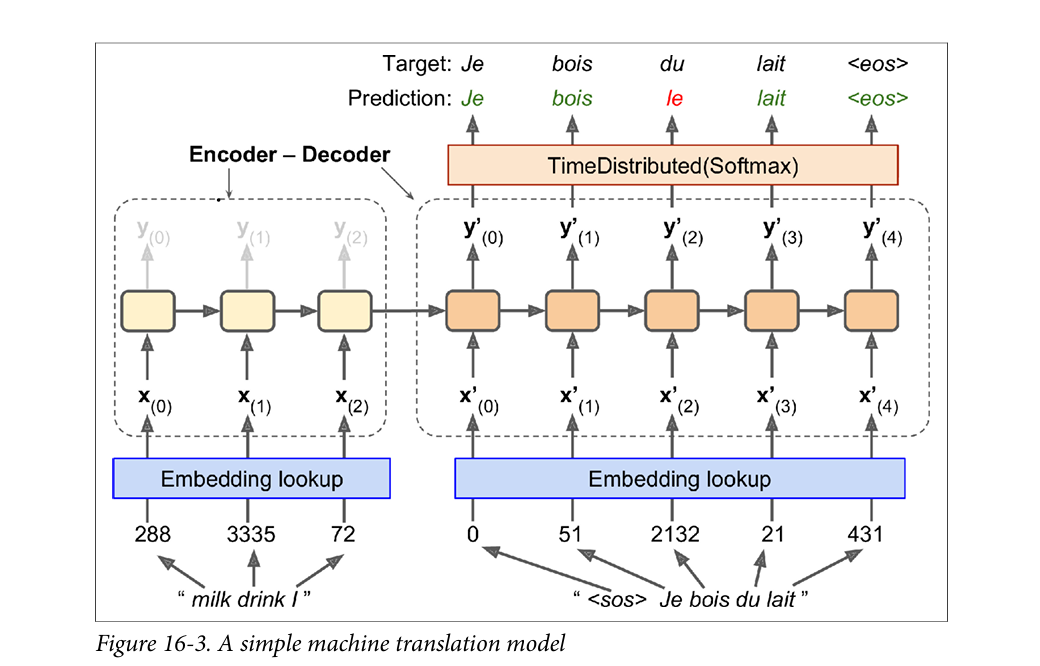

In [ ]:
import tensorflow_addons as tfa
encoder_inputs = keras.layers.Input(shape=[None], dtype =np.int32)
decoder_inputs = keras.layers.Input(shape=[None],dtype = np.int32)
sequence_lenghts = keras.layers.Input(shape=[], dtype =np.int32)


embeddings = keras.layers.Embeddigns(vocab_size ,embed_size)
encoder_embeddings = embeddings(encoder_inputs)
decoder_embeddings = embeddings(decoder_inputs)


encoder = keras.layers.LSTM(512 , return_state = True)
encoder_outputs , state_h , state_c = encoder(encoder_embeddings)
encoder_states = [state_h , state_c]



sampler = tfa.seq2seq.sampler.TrainingSampler()

decoder_cell = keras.layers.LSTMCell(512)
output_layer = keras.layers.Dense(vocab_size)
decoder = tfa.seq2seq.BasicDecoder(decoder_cell , sampler , output_layer)

final_outputs , final_state , final_sequence_lengths = decoder(decoder_embeddings , initial_state = encoder_states , sequence_length = sequence_lenghts)            
Y_proba = tf.nn.softmax(final_outputs.rnn_output)
model = keras.Model(inputs=[encoder_inputs , decoder_inputs , sequence_lenghts] , outputs=[Y_proba])
model.compile(loss = "sparse_categorical_crossentropy" , optimizer = "adam" , metrics=["accuracy"])

### Bidirectional RNNs
-run two
recurrent layers on the same inputs, one reading the words from left to right and the
other reading them from right to left
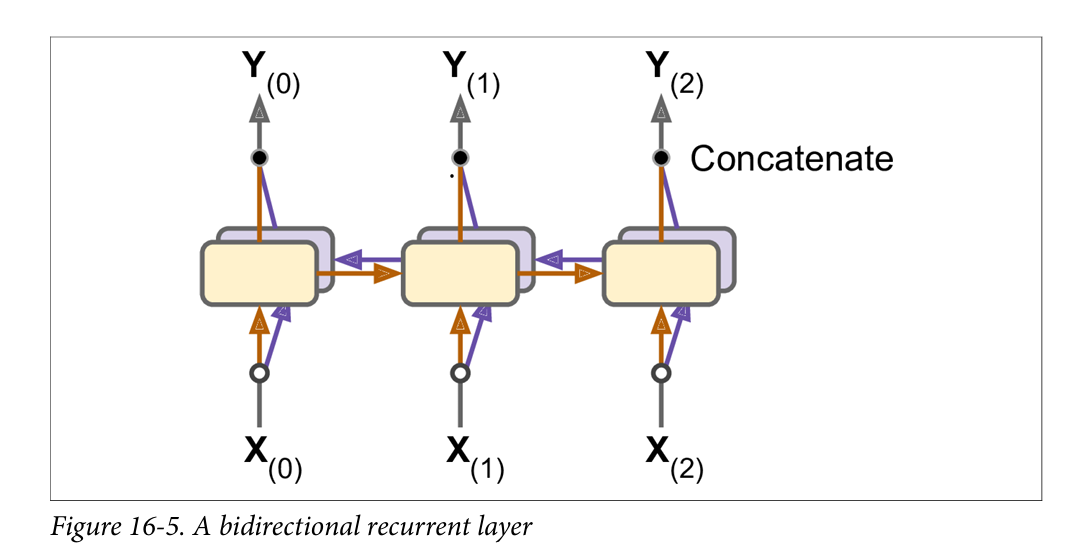



In [ ]:
keras.layers.Bidirectional(keras.layers.GRU(10,return_sequences=True))

### Attention mechanism
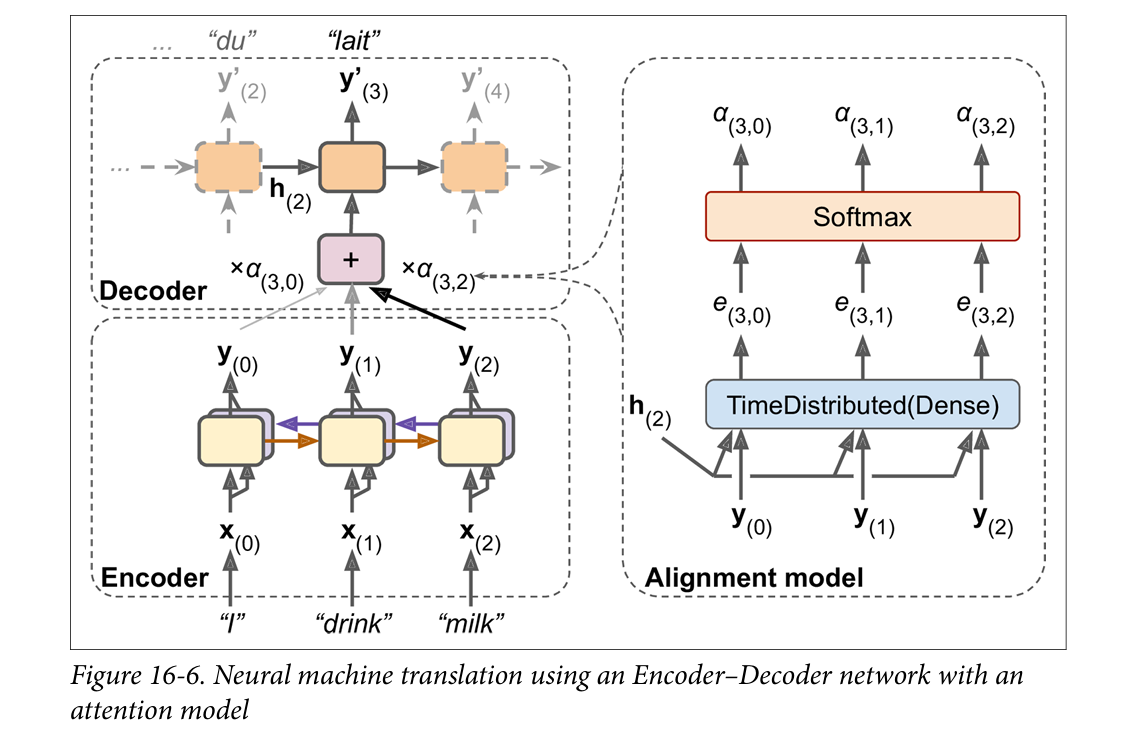


-Equation



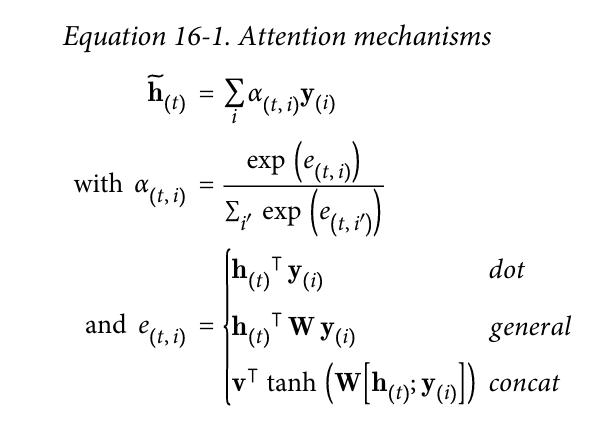

In [ ]:
attention_mechanism = tfa.seq2seq.attention_wrapper.LuongAttention(
units, encoder_state, memory_sequence_length=encoder_sequence_length)
attention_decoder_cell = tfa.seq2seq.attention_wrapper.AttentionWrapper(
decoder_cell, attention_mechanism, attention_layer_size=n_units)

### Positional Embeddings

In [ ]:
class PositionalEncoding(keras.layers.Layer):
    def __init__(self, max_steps, max_dims, dtype=tf.float32, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        if max_dims % 2 == 1:
            max_dims += 1  # max_dims must be even

        p, i = np.meshgrid(np.arange(max_steps), np.arange(max_dims // 2))
        pos_emb = np.empty((1, max_steps, max_dims))
        pos_emb[0, :, ::2] = np.sin(p / 10000 ** (2 * i / max_dims)).T
        pos_emb[0, :, 1::2] = np.cos(p / 10000 ** (2 * i / max_dims)).T
        self.positional_embedding = tf.constant(pos_emb.astype(self.dtype))

    def call(self, inputs):
        shape = tf.shape(inputs)
        return inputs + self.positional_embedding[:, :shape[-2], :shape[-1]]
    


    #create the first layers of the transformer

    embed_size = 512 ; max_steps=500 ; vocab_size = 10000
    encoder_inputs = keras.layers.Input(shape=[None], dtype=np.int32)
    decoder_inputs = keras.layers.Input(shape=[None], dtype=np.int32)
    embeddings = keras.layers.Embedding(vocab_size, embed_size)
    encoder_embeddings = embeddings(encoder_inputs)
    decoder_embeddings = embeddings(decoder_inputs)
    positionak_encoding = PositionalEncoding(max_steps, embed_size)
    encoder_embeddings = positionak_encoding(encoder_embeddings)
    decoder_embeddings = positionak_encoding(decoder_embeddings)
